# Late Delivery Risk Modeling Project
Winter, 2025

### 1. Load Data & Inspect

In [1]:
import pandas as pd

# Load
DATA_PATH = "F:/wolt_assignment_Negin_Hadad/wolt_assignment_Negin_Hadad/data/orders_spring_2022.csv"  # set the data file path
df = pd.read_csv(DATA_PATH)

# Inspection
print("\n Shape:", df.shape)
display(df.head())

# Data types
print("\n Info:")
df.info()

# Statistics
print("\n Describe:")
display(df.describe())


 Shape: (24942, 10)


,order_placed_at_utc,order_category,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,venue_location_h3_index,customer_location_h3_index,courier_supply_index,precipitation
0,2022-02-01T06:01:00.000000,Retail,9,23.373547,15.0,25.0,881126d307fffff,881126d307fffff,1.48,0.0
1,2022-02-01T06:16:00.000000,Food delivery,2,72.864126,40.0,50.0,881126d339fffff,881126d311fffff,1.49,0.0
2,2022-02-01T06:46:00.000000,Food delivery,3,48.737269,30.0,40.0,881126d33dfffff,881126d331fffff,1.50,0.0
3,2022-02-01T07:17:00.000000,Food delivery,5,37.744732,35.0,45.0,881126d331fffff,881126d337fffff,1.56,0.0
4,2022-02-01T07:21:00.000000,Retail,15,68.881136,35.0,45.0,881126d06bfffff,881126d027fffff,1.58,0.0



 Info:
<class 'pandas.DataFrame'>
RangeIndex: 24942 entries, 0 to 24941
Data columns (total 10 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   order_placed_at_utc                    24942 non-null  str    
 1   order_category                         24942 non-null  str    
 2   item_count                             24942 non-null  int64  
 3   actual_delivery_time_minutes           24942 non-null  float64
 4   estimated_delivery_time_lower_minutes  24886 non-null  float64
 5   estimated_delivery_time_upper_minutes  24886 non-null  float64
 6   venue_location_h3_index                24942 non-null  str    
 7   customer_location_h3_index             24942 non-null  str    
 8   courier_supply_index                   24844 non-null  float64
 9   precipitation                          24072 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 1.9 MB

 Describe:


,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,courier_supply_index,precipitation
count,24942.000000,24942.000000,24886.000000,24886.000000,24844.000000,24072.000000
mean,3.534761,34.655144,25.404846,35.540465,1.740127,0.101587
std,4.900008,120.366646,10.976981,10.992501,0.245377,0.356154
min,1.000000,0.022010,0.000000,5.000000,1.000000,0.000000
25%,1.000000,22.094178,20.000000,30.000000,1.570000,0.000000
50%,2.000000,29.732429,25.000000,35.000000,1.740000,0.000000
75%,4.000000,40.186852,30.000000,40.000000,1.910000,0.000000
max,100.000000,15631.062016,80.000000,90.000000,2.640000,3.400000


### 2. Create "delayed" Label

In [2]:
df["order_placed_at_utc"] = pd.to_datetime(df["order_placed_at_utc"], errors="coerce") # Ensure that the column is datetime

# Create target label
df["delayed"] = (df["actual_delivery_time_minutes"] > df["estimated_delivery_time_upper_minutes"]).astype(int)

# Check Label statics
print("\n Late label value counts: \n", df["delayed"].value_counts())
print(f"\nLate delivery rate: {df['delayed'].mean()*100:.2f}%")
display(df[["actual_delivery_time_minutes", "estimated_delivery_time_upper_minutes", "delayed"]].sample(5))


 Late label value counts: 
 delayed
0    16111
1     8831
Name: count, dtype: int64

Late delivery rate: 35.41%


,actual_delivery_time_minutes,estimated_delivery_time_upper_minutes,delayed
11927,23.055781,30.0,0
8341,27.930721,25.0,1
5869,49.835745,45.0,1
8100,39.132178,45.0,0
3173,56.763582,35.0,1


### 3. Extract Data

In [3]:
import numpy as np

# Time Features:
df["hour"] = df["order_placed_at_utc"].dt.hour # => [0, 23]
df["day_of_week"] = df["order_placed_at_utc"].dt.dayofweek  # => [0, 6], Monday=0, ..
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int) # => 0/1

# Cyclical Encoding:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Check Validity
display(df[["order_placed_at_utc", "hour",  "day_of_week", "is_weekend","hour_sin", "hour_cos"]].sample(10))

,order_placed_at_utc,hour,day_of_week,is_weekend,hour_sin,hour_cos
625,2022-02-03 11:06:00,11,3,0,2.588190e-01,-0.965926
4293,2022-02-15 19:06:00,19,1,0,-9.659258e-01,0.258819
15584,2022-03-27 13:03:00,13,6,1,-2.588190e-01,-0.965926
20509,2022-04-13 16:30:00,16,2,0,-8.660254e-01,-0.500000
21062,2022-04-15 16:22:00,16,4,0,-8.660254e-01,-0.500000
21048,2022-04-15 15:44:00,15,4,0,-7.071068e-01,-0.707107
819,2022-02-04 08:03:00,8,4,0,8.660254e-01,-0.500000
5722,2022-02-20 16:11:00,16,6,1,-8.660254e-01,-0.500000
7570,2022-02-27 12:12:00,12,6,1,1.224647e-16,-1.000000
16352,2022-03-30 09:35:00,9,2,0,7.071068e-01,-0.707107


### 4. Anaysis

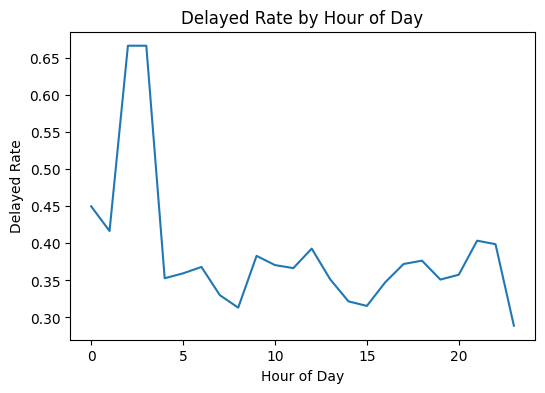

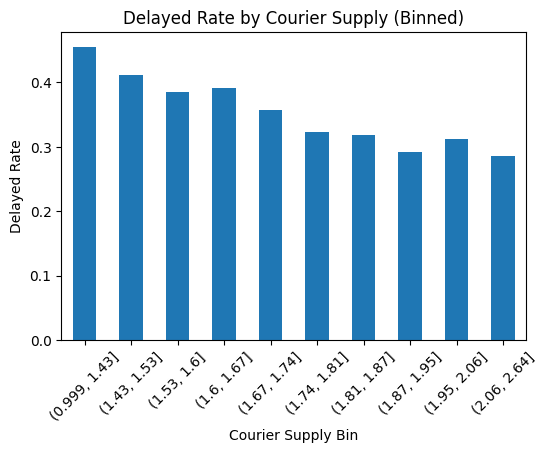

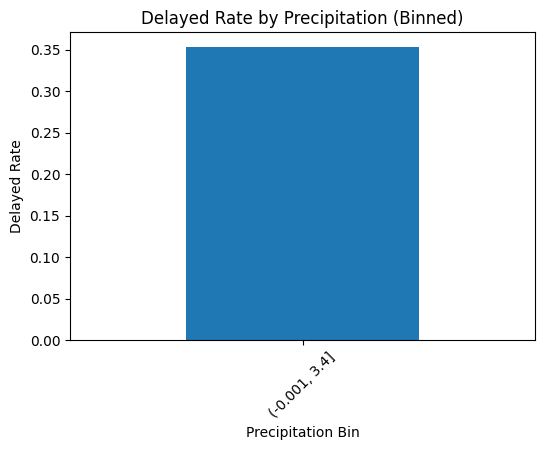

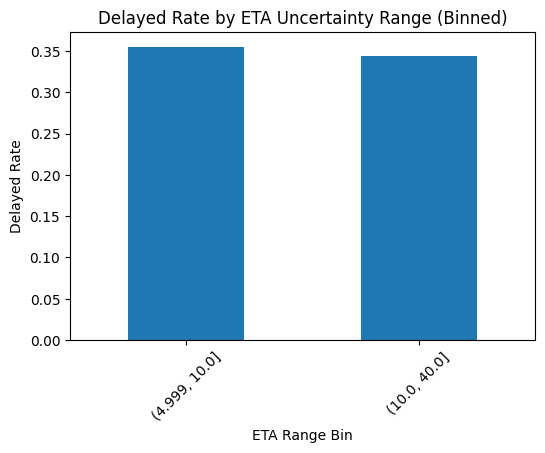

In [4]:
import matplotlib.pyplot as plt

# 1. Delayed Rate by Hour:
hour_stats = df.groupby("hour")["delayed"].mean()

plt.figure(figsize=(6, 4))
hour_stats.plot()
plt.title("Delayed Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Delayed Rate")
plt.show()

#  2. Delayed Rate by Courier Supply:
df["supply_bin"] = pd.qcut(df["courier_supply_index"], q=10, duplicates="drop")
supply_stats = df.groupby("supply_bin", observed=False)["delayed"].mean()

plt.figure(figsize=(6, 4))
supply_stats.plot(kind="bar")
plt.title("Delayed Rate by Courier Supply (Binned)")
plt.xlabel("Courier Supply Bin")
plt.ylabel("Delayed Rate")
plt.xticks(rotation=45)
plt.show()

# 3. Delayed Rate by Precipitation:
df["precip_bin"] = pd.qcut(df["precipitation"], q=6, duplicates="drop")
precip_stats = df.groupby("precip_bin", observed=False)["delayed"].mean()

plt.figure(figsize=(6, 4))
precip_stats.plot(kind="bar")
plt.title("Delayed Rate by Precipitation (Binned)")
plt.xlabel("Precipitation Bin")
plt.ylabel("Delayed Rate")
plt.xticks(rotation=45)
plt.show()

# 4. Delayed Rate by ETA Range:
df["eta_range"] = (df["estimated_delivery_time_upper_minutes"] - df["estimated_delivery_time_lower_minutes"])
df["eta_bin"] = pd.qcut(df["eta_range"], q=10, duplicates="drop")
eta_stats = df.groupby("eta_bin", observed=False)["delayed"].mean()

plt.figure(figsize=(6, 4))
eta_stats.plot(kind="bar")
plt.title("Delayed Rate by ETA Uncertainty Range (Binned)")
plt.xlabel("ETA Range Bin")
plt.ylabel("Delayed Rate")
plt.xticks(rotation=45)
plt.show()

### 5. Data Preparation

In [5]:
# 1. Feature Selection
df["same_hex"] = (df["venue_location_h3_index"] == df["customer_location_h3_index"]).astype(int)
y = df["delayed"]
feature_cols = [
    "hour", "day_of_week", "is_weekend", "hour_sin", "hour_cos",
    "item_count", "order_category",
    "estimated_delivery_time_lower_minutes", "estimated_delivery_time_upper_minutes", "eta_range",
    "courier_supply_index",
    "precipitation",
    "same_hex"
]
X = df[feature_cols].copy()
X["order_category"] = X["order_category"].astype("category").cat.codes

# 2. Missing Value Handling
print(X.isna().sum()) # analyze primary codition
numeric_cols = X.select_dtypes(include=np.number).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# 3. Split Data
df_sorted = df.sort_values("order_placed_at_utc").reset_index(drop=True)
X = X.loc[df_sorted.index]
y = y.loc[df_sorted.index]

train_end = int(len(df_sorted) * 0.7)
val_end = int(len(df_sorted) * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print("\n Train Data Size: ", X_train.shape)
print("Validation Data Size: ", X_val.shape)
print("Test Data Size: ", X_test.shape)

print("Class Balance in Train(delayed=0/1): \n", y_train.value_counts(normalize=True))

hour                                       0
day_of_week                                0
is_weekend                                 0
hour_sin                                   0
hour_cos                                   0
item_count                                 0
order_category                             0
estimated_delivery_time_lower_minutes     56
estimated_delivery_time_upper_minutes     56
eta_range                                 56
courier_supply_index                      98
precipitation                            870
same_hex                                   0
dtype: int64

 Train Data Size:  (17459, 13)
Validation Data Size:  (3741, 13)
Test Data Size:  (3742, 13)
Class Balance in Train(delayed=0/1): 
 delayed
0    0.641102
1    0.358898
Name: proportion, dtype: float64


### 6. Baseline Model

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve

# 1. Scaling
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

scale_cols = X_train.select_dtypes(include=np.number).columns

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

# 2. Train
model = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
model.fit(X_train_scaled, y_train)

# 3. Probability Prediction
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluation
roc = roc_auc_score(y_val, y_val_proba)
pr = average_precision_score(y_val, y_val_proba)

print(f"Validation ROC-AUC: {roc:.4f}")
print(f"Validation PR-AUC: {pr:.4f}")

# 5. Threshold Analysis
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
target_recall = 0.7
idx = np.where(recall >= target_recall)[0][-1]
chosen_threshold = thresholds[idx]

print(f"Chosen Threshold: {chosen_threshold:.4f}")
print(f"Precision at Threshold: {precision[idx]:.4f}")
print(f"Recall at Threshold: {recall[idx]:.4f}")

Validation ROC-AUC: 0.6328
Validation PR-AUC: 0.4968
Chosen Threshold: 0.4950
Precision at Threshold: 0.3986
Recall at Threshold: 0.7004


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### 7.1 Extract coefficients

,feature,coefficient,abs_coef
10,courier_supply_index,-0.227191,0.227191
6,order_category,-0.204174,0.204174
5,item_count,0.131713,0.131713
8,estimated_delivery_time_upper_minutes,-0.125954,0.125954
3,hour_sin,-0.125543,0.125543
9,eta_range,-0.124141,0.124141
0,hour,-0.116663,0.116663
7,estimated_delivery_time_lower_minutes,-0.108622,0.108622
11,precipitation,0.046785,0.046785
12,same_hex,-0.038338,0.038338


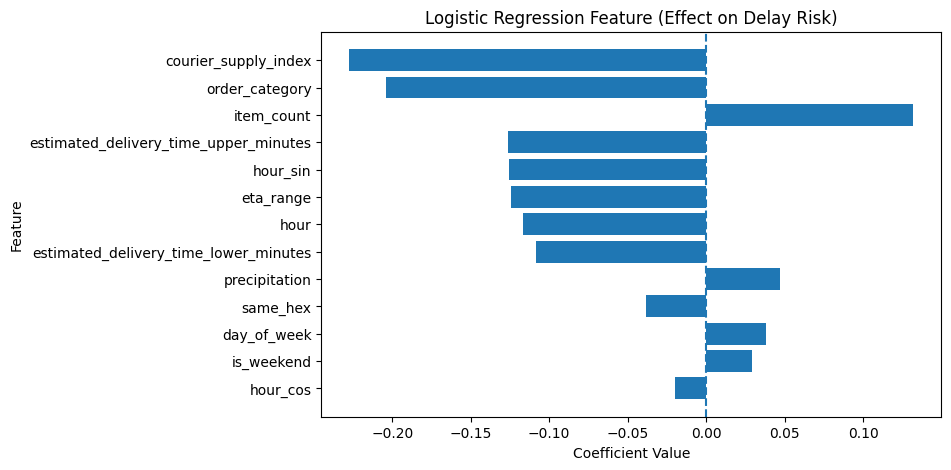

In [7]:
feature_importance = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": model.coef_[0]
})

feature_importance["abs_coef"] = feature_importance["coefficient"].abs()
feature_importance = feature_importance.sort_values("abs_coef", ascending=False)

display(feature_importance)

# Visualization
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["feature"],
    feature_importance["coefficient"]
)
plt.axvline(0, linestyle="--")
plt.title("Logistic Regression Feature (Effect on Delay Risk)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### 8. Error Analysis

In [8]:
from sklearn.metrics import confusion_matrix

# 1. Create Confusion Matrix
y_val_pred = (y_val_proba >= chosen_threshold).astype(int) # convert probabilities to decisions

cm = confusion_matrix(y_val, y_val_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual_OnTime", "Actual_Delayed"],
    columns=["Pred_OnTime", "Pred_Delayed"]
)

display(cm_df)

# 2. Analyze FN and FP Cases
val_df = X_val.copy()
val_df["true"] = y_val.values
val_df["proba"] = y_val_proba
val_df["pred"] = y_val_pred

false_negatives = val_df[(val_df["true"] == 1) & (val_df["pred"] == 0)]
false_positives = val_df[(val_df["true"] == 0) & (val_df["pred"] == 1)]
display(false_negatives.sample(10))
display(false_positives.sample(10))

,Pred_OnTime,Pred_Delayed
Actual_OnTime,1139,1337
Actual_Delayed,379,886


,hour,day_of_week,is_weekend,hour_sin,hour_cos,item_count,order_category,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,eta_range,courier_supply_index,precipitation,same_hex,true,proba,pred
19004,12,4,0,1.224647e-16,-1.000000e+00,2,0,35.0,45.0,10.0,1.78,0.0,0,1,0.459043,0
20791,15,3,0,-7.071068e-01,-7.071068e-01,10,1,25.0,35.0,10.0,1.91,0.0,0,1,0.382205,0
20777,15,3,0,-7.071068e-01,-7.071068e-01,4,0,20.0,30.0,10.0,2.06,0.0,0,1,0.486229,0
17621,11,6,1,2.588190e-01,-9.659258e-01,2,0,20.0,35.0,15.0,1.81,0.0,0,1,0.438818,0
17987,13,0,0,-2.588190e-01,-9.659258e-01,3,0,35.0,45.0,10.0,1.85,0.0,0,1,0.433891,0
19514,18,5,1,-1.000000e+00,-1.836970e-16,2,0,30.0,45.0,15.0,1.53,0.2,0,1,0.444724,0
19121,15,4,0,-7.071068e-01,-7.071068e-01,1,0,35.0,45.0,10.0,1.96,0.0,0,1,0.416860,0
19529,18,5,1,-1.000000e+00,-1.836970e-16,1,0,35.0,50.0,15.0,1.55,0.2,0,1,0.408203,0
18018,14,0,0,-5.000000e-01,-8.660254e-01,4,0,50.0,60.0,10.0,2.11,0.0,0,1,0.313621,0
20652,10,3,0,5.000000e-01,-8.660254e-01,8,1,15.0,25.0,10.0,1.82,1.2,0,1,0.467463,0


,hour,day_of_week,is_weekend,hour_sin,hour_cos,item_count,order_category,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,eta_range,courier_supply_index,precipitation,same_hex,true,proba,pred
20040,15,0,0,-0.707107,-7.071068e-01,2,0,15.0,25.0,10.0,1.88,0.0,1,0,0.500350,1
20542,18,2,0,-1.000000,-1.836970e-16,2,0,20.0,30.0,10.0,1.35,0.0,1,0,0.586944,1
19821,16,6,1,-0.866025,-5.000000e-01,2,0,10.0,20.0,10.0,1.79,0.0,0,0,0.612747,1
17926,9,0,0,0.707107,-7.071068e-01,2,0,20.0,30.0,10.0,1.58,0.0,0,0,0.550844,1
20646,9,3,0,0.707107,-7.071068e-01,1,0,25.0,35.0,10.0,2.01,1.9,0,0,0.500958,1
18062,16,0,0,-0.866025,-5.000000e-01,3,0,20.0,30.0,10.0,1.84,0.0,0,0,0.512524,1
17914,9,0,0,0.707107,-7.071068e-01,2,0,20.0,30.0,10.0,1.58,0.0,0,0,0.550844,1
18700,9,3,0,0.707107,-7.071068e-01,2,0,25.0,35.0,10.0,1.69,0.0,0,0,0.514337,1
19569,7,6,1,0.965926,-2.588190e-01,1,0,35.0,45.0,10.0,1.44,0.0,0,0,0.542475,1
18196,9,1,0,0.707107,-7.071068e-01,3,0,15.0,25.0,10.0,1.77,0.0,1,0,0.519453,1
